# -----------------------------AI LAB FINAL PROJECT-------------------------------------
#
# --------------------------------Group Members----------------------------------------
#
## -------------------------------1. Abdul Azeem Javaid (24P-0523)---------------------------------------
## --------------------------2. Malik Muhammad Sanaullah (24P-0554)-----------------------------------


In [22]:
# Basic Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

# for splitting dataset into train and test
from sklearn.model_selection import train_test_split

# for knn
from sklearn.neighbors import KNeighborsClassifier

# for calculating accuracy
from sklearn.metrics import accuracy_score

# for naive bayes
from sklearn.naive_bayes import GaussianNB

# for logistic regression 
from sklearn.linear_model import LogisticRegression

# for normalizing or scaling features
from sklearn.preprocessing import StandardScaler

# for k-means clustering
from sklearn.cluster import KMeans

# for reducing features to 2D for visualization
from sklearn.decomposition import PCA


# TASK # 01
## Data Exploration


In [41]:
# loading the dataset using pandas
df = pd.read_csv("network_traffic.csv")

# printing basic info about the dataset
print(f"Size of the dataset is: {df.size}")
print(f"Shape of the dataset is: {df.shape}")
print(f"\nFirst 5 rows of the dataset:{df.head()}")

Size of the dataset is: 96000
,Shape of the dataset is: (6000, 16)
,
,First 5 rows of the dataset:   duration  src_bytes  dst_bytes  wrong_fragment  hot  logged_in  \
,0         0        244       3252               0    0          1   
,1         0          8          0               0    0          0   
,2         0        242       5278               0    0          1   
,3         0         45         76               0    0          0   
,4         0          1          0               0    0          0   
,
,   num_compromised  count  srv_count  serror_rate  same_srv_rate  \
,0                0     16         16          0.0           1.00   
,1                0      1         21          0.0           1.00   
,2                0      6         11          0.0           1.00   
,3                0    161        161          0.0           1.00   
,4                0     13          2          0.0           0.15   
,
,   diff_srv_rate  dst_host_count  dst_host_srv_count  dst_host_s

In [24]:
# printing statistical summary of all numeric columns
print(f"Statistical Summary (only for numeric values) is given below:\n")
print(df.describe())

Statistical Summary (only for numeric values) is given below:
,
,           duration     src_bytes     dst_bytes  wrong_fragment          hot  \
,count   6000.000000  6.000000e+03  6.000000e+03     6000.000000  6000.000000   
,mean     413.933000  1.603307e+04  2.951740e+03        0.028333     0.206167   
,std     3237.030266  3.049754e+05  7.057366e+04        0.283803     2.120632   
,min        0.000000  0.000000e+00  0.000000e+00        0.000000     0.000000   
,25%        0.000000  0.000000e+00  0.000000e+00        0.000000     0.000000   
,50%        0.000000  4.300000e+01  0.000000e+00        0.000000     0.000000   
,75%        0.000000  2.730000e+02  4.550000e+02        0.000000     0.000000   
,max    42569.000000  1.698050e+07  5.149533e+06        3.000000    30.000000   
,
,         logged_in  num_compromised        count    srv_count  serror_rate  \
,count  6000.000000      6000.000000  6000.000000  6000.000000  6000.000000   
,mean      0.385000         0.179667    80.4345

Normal: 3000
,Attack: 3000


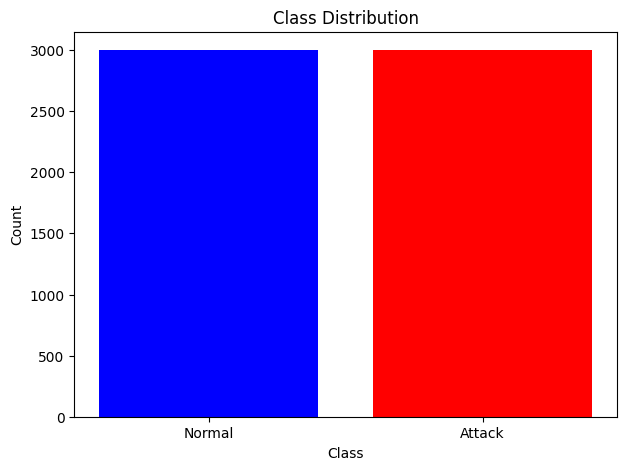

In [25]:
# we will create a bar chart which compares the number of normals and attacks in the dataset

# counting normal and attack records
# 0 for normal and 1 for attack
normal_count=df[df['label']==0].shape[0]
attack_count=df[df['label']==1].shape[0]

# print values
print("Normal:", normal_count)
print("Attack:", attack_count)

# creating bar chart
plt.figure(figsize=(7, 5))
plt.bar(['Normal', 'Attack'], [normal_count, attack_count], color=['blue', 'red'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

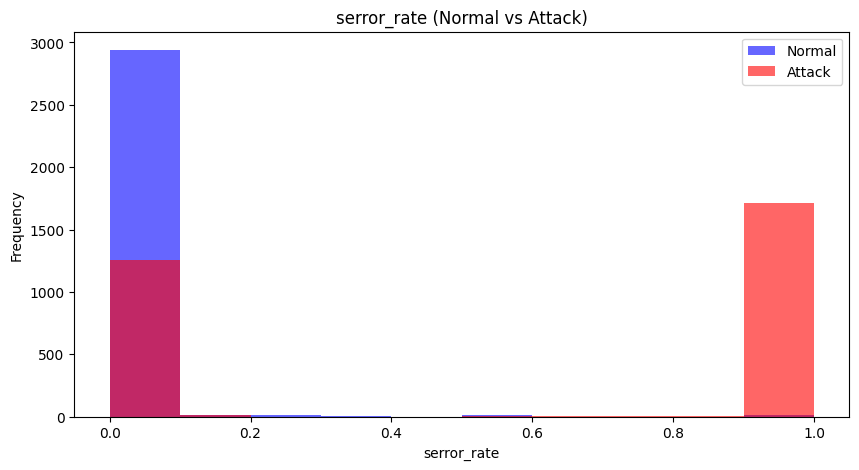

In [44]:
# splitting dataset by class so we can plot each class separately
normal=df[df['label']==0]
attack=df[df['label']==1]

# plotting histogram for serror_rate feature
plt.figure(figsize=(10, 5))
plt.hist(normal['serror_rate'], bins=10, alpha=0.6, color='blue', label='Normal')
plt.hist(attack['serror_rate'], bins=10, alpha=0.6, color='red', label='Attack')
plt.title('serror_rate (Normal vs Attack)')
plt.xlabel('serror_rate')
plt.ylabel('Frequency')
plt.legend()
plt.show()

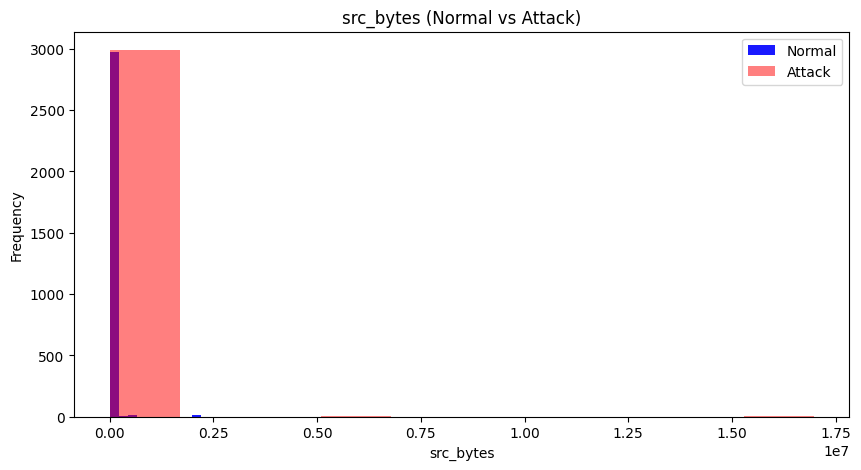

In [45]:
# plotting histogram for src_bytes feature
plt.figure(figsize=(10, 5))
plt.hist(normal['src_bytes'], bins=10, alpha=0.9, color='blue', label='Normal')
plt.hist(attack['src_bytes'], bins=10, alpha=0.5, color='red', label='Attack')
plt.title('src_bytes (Normal vs Attack)')
plt.xlabel('src_bytes')
plt.ylabel('Frequency')
plt.legend()
plt.show()


# Task # 02
## Simple Reflex Agent


In [47]:
# A simple reflex agent

# we picked these three features from the histograms above
# because they show a clear difference between normal and attack traffic

def reflex_agent(row):
    if row['serror_rate'] > 0.5:
        return 1
        
    if row['same_srv_rate']==1.0 and row['logged_in']==0:
        return 1
        
    if row['count']>200 and row['logged_in']==0:
        return 1
        
    return 0


# applying the reflex agent to every row in the dataset, to store the prediction
y_reflex=[]

for i in range(len(df)):
    y_reflex.append(reflex_agent(df.iloc[i]))

# true labels for the whole dataset
y_all=df['label'].tolist()

# manually counting correct predictions
correct=0

for i in range(len(y_all)):
    if y_all[i]==y_reflex[i]:
        correct=correct+1

# calculating accuracy
reflex_accuracy=correct/len(y_all)

print("Reflex Agent Accuracy:", reflex_accuracy)

# manually building the confusion matrix

tp=0 # predicted attack, actually attack
tn=0 # predicted normal, actually normal
fp=0 # predicted attack, actually normal
fn=0 # predicted normal, actually attack

for i in range(len(y_all)):
    if y_all[i]==1 and y_reflex[i]==1:
        tp=tp+1

    elif y_all[i]==0 and y_reflex[i]==0:
        tn=tn+1

    elif y_all[i]==0 and y_reflex[i]==1:
        fp=fp+1

    elif y_all[i]==1 and y_reflex[i]==0:
        fn=fn+1

print("\nConfusion Matrix:\n")
print("True Normal:\tPredicted Normal:", tn)
print("True Normal:\tPredicted Attack:", fp)
print("True Attack:\tPredicted Normal:", fn)
print("True Attack:\tPredicted Attack:", tp)

Reflex Agent Accuracy: 0.8023333333333333
,
,Confusion Matrix:
,
,True Normal:	Predicted Normal: 2278
,True Normal:	Predicted Attack: 722
,True Attack:	Predicted Normal: 464
,True Attack:	Predicted Attack: 2536


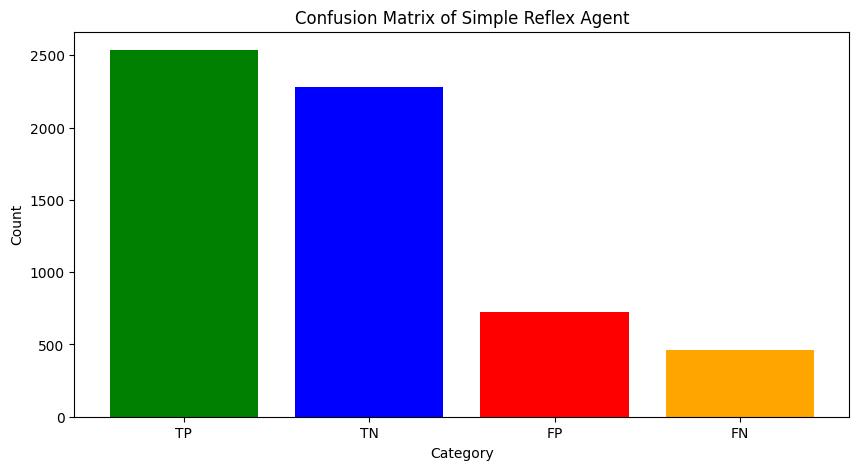

In [48]:
# creating a bar chart to visualize the confusion matrix values
plt.figure(figsize=(10, 5))
plt.bar(['TP', 'TN', 'FP', 'FN'], [tp, tn, fp, fn], color=['green', 'blue', 'red', 'orange'])
plt.title('Confusion Matrix of Simple Reflex Agent')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

# Task # 03
## Supervised Learning


In [50]:
# listing all 15 feature columns except the label column

feature_columns=['duration','src_bytes','dst_bytes','wrong_fragment','hot','logged_in',
                   'num_compromised','count','srv_count','serror_rate','same_srv_rate',
                   'diff_srv_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate']

# separating features and target label
x=df[feature_columns].values
y=df['label'].values

# splitting data (80% for train and 20% for test)
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# stratify=y makes sure both splits have equal ratio of normal/attack
# random_state=42 keeps the split the same every time we run

# scaling features using StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train) # fit and transform training data
x_test_scaled=scaler.transform(x_test) # only transforming test

# print sizes
print("Train samples:", len(x_train))
print("Test samples:", len(x_test))

Train samples: 4800
,Test samples: 1200


In [56]:
# trying different values of k to find which one gives the best accuracy
k_values=[1,3,5,7,9,11]
accuracies=[]

for k in k_values:
    # creating and training the KNN classifier
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train_scaled, y_train)

    # predicting on test data
    preds=knn.predict(x_test_scaled)

    # calculating accuracy and saving it
    acc = accuracy_score(y_test, preds)
    accuracies.append(acc)
    print("k =", k, ":    Accuracy =", acc)

# finding the best k manually
best_k=k_values[0]
best_acc=accuracies[0]

for i in range(len(k_values)):
    if accuracies[i]>best_acc:
        best_acc=accuracies[i]
        best_k=k_values[i]

print("\nBest k =", best_k, "with Accuracy =", best_acc)

k = 1 :    Accuracy = 0.9575
,k = 3 :    Accuracy = 0.9575
,k = 5 :    Accuracy = 0.9558333333333333
,k = 7 :    Accuracy = 0.9533333333333334
,k = 9 :    Accuracy = 0.9516666666666667
,k = 11 :    Accuracy = 0.9475
,
,Best k = 1 with Accuracy = 0.9575


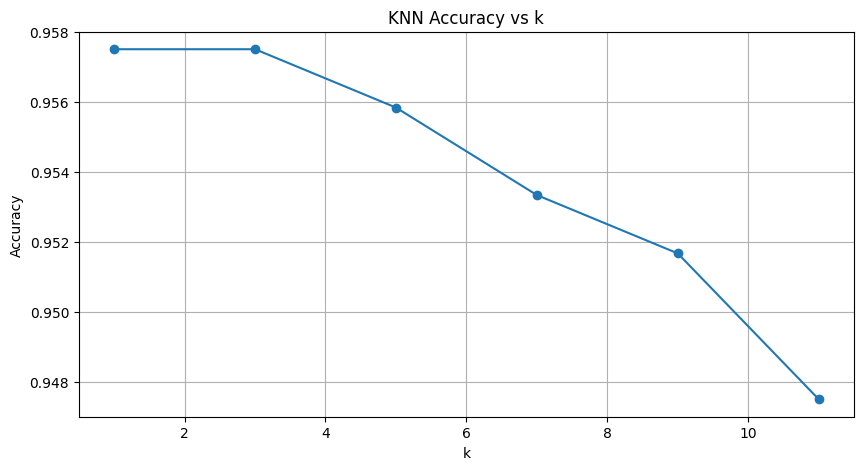

In [57]:
# plotting accuracy vs k
plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker='o')
plt.title('KNN Accuracy vs k')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

In [62]:
# Naive Bayes:


nb=GaussianNB()
nb.fit(x_train, y_train)
nb_pred = nb.predict(x_test)
nb_acc = accuracy_score(y_test, nb_pred)
print("Naive Bayes Accuracy:\t\t", nb_acc)

# Logistic Regression


# Logistic Regression needs scaled data
lr= LogisticRegression(max_iter=1000)
lr.fit(x_train_scaled, y_train)   # using scaled data
lr_pred=lr.predict(x_test_scaled)
lr_acc=accuracy_score(y_test, lr_pred)
print("\nLogistic Regression Accuracy:   ", lr_acc)

# KNN with Best k


# training final KNN model using the best k we found above
knn_best=KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(x_train_scaled, y_train)
knn_pred=knn_best.predict(x_test_scaled)
knn_acc=accuracy_score(y_test, knn_pred)
print("\nKNN (k=", best_k, ") Accuracy:\t\t", knn_acc)

Naive Bayes Accuracy:		 0.7875
,
,Logistic Regression Accuracy:    0.915
,
,KNN (k= 1 ) Accuracy:		 0.9575


In [ ]:
# saving predictions as lists so we can use them in get_metrics()
y_test_list=y_test.tolist()
y_pred_knn=knn_pred.tolist()
y_pred_nb=nb_pred.tolist()
y_pred_lr=lr_pred.tolist()

In [67]:
# helper function to calculate accuracy, precision, recall and f1 manually
# we compute everything from the confusion matrix values

def get_metrics(true, pred):
    tp=0
    tn=0
    fp=0
    fn=0
    
    for i in range(len(true)):
        if true[i]==1 and pred[i]==1:
            tp=tp+1
            
        elif true[i]==0 and pred[i]==0:
            tn=tn+1

        elif true[i]==0 and pred[i]==1:
            fp=fp+1
            
        elif true[i]==1 and pred[i]==0:
            fn=fn+1
            
    # accuracy =correct predictions / total predictions
    accuracy=(tp+tn)/(tp+tn+fp+fn)

    # precision=out of all predicted attacks, how many of them were actually attacks
    precision=tp/(tp+fp) if (tp+fp)>0 else 0

    # recall=out of all actual attacks, how many we have catched
    recall=tp/(tp+fn) if (tp+fn)>0 else 0

    # f1 = harmonic mean of precision and recall
    f1=2*precision*recall/(precision + recall) if (precision+recall)>0 else 0

    return accuracy, precision, recall, f1


# calculating metrics for all four models
# y_all and y_reflex are used for reflex agent
# y_test_list is used for ML models

reflex_acc,reflex_pre,reflex_rec,reflex_f1=get_metrics(y_all,y_reflex)

knn_acc,knn_pre,knn_rec,knn_f1=get_metrics(y_test_list,y_pred_knn)

nb_acc,nb_pre,nb_rec,nb_f1=get_metrics(y_test_list,y_pred_nb)

lr_acc,lr_pre,lr_rec,lr_f1=get_metrics(y_test_list,y_pred_lr)

# printing comparison table
print("Model\t\t\tAccuracy\tPrecision\tRecall\t\tF1\n")
print("Simple Reflex Agent\t", round(reflex_acc, 4), "\t", round(reflex_pre, 4), "\t", round(reflex_rec, 4), "\t", round(reflex_f1, 4))
print("KNN (k=", best_k, ")\t\t", round(knn_acc, 4), "\t", round(knn_pre, 4), "\t\t", round(knn_rec, 4), "\t", round(knn_f1, 4))
print("Naive Bayes\t\t", round(nb_acc, 4), "\t", round(nb_pre, 4), "\t", round(nb_rec, 4), "\t", round(nb_f1, 4))
print("Logistic Regression\t", round(lr_acc, 4), "\t\t", round(lr_pre, 4), "\t", round(lr_rec, 4), "\t", round(lr_f1, 4))

Model			Accuracy	Precision	Recall		F1
,
,Simple Reflex Agent	 0.8023 	 0.7784 	 0.8453 	 0.8105
,KNN (k= 1 )		 0.9575 	 0.9493 	 0.9667 	 0.9579
,Naive Bayes		 0.7875 	 0.9367 	 0.6167 	 0.7437
,Logistic Regression	 0.915 		 0.9249 	 0.9033 	 0.914


# Task # 04
## Clustering with K-Means


In [69]:
# preparing features
x_km=df[feature_columns].values
y_true=df['label'].values

# scaling features before clustering
scaler_km=StandardScaler()
x_scaled=scaler_km.fit_transform(x_km)

# fitting K-means with 2 clusters (one for normal, one for attack)
kmeans=KMeans(n_clusters=2, random_state=42, n_init=10) # n_init=10 runs the algorithm 10 times and picks the best result
y_pred=kmeans.fit_predict(x_scaled)

# K-Means does not know which cluster is normal and which is attack
# so we check if the clusters are flipped and fix it if needed
normal_match=0
attack_match=0

for i in range(len(y_true)):
    if y_true[i]==y_pred[i]:
        normal_match=normal_match+1
        
    if y_true[i]==(1-y_pred[i]):
        attack_match=attack_match+1
        
# if more rows match when flipped then the clusters are reversed -- fix them
if attack_match>normal_match:
    for i in range(len(y_pred)):
        y_pred[i]=1-y_pred[i]
    print("Clusters were flipped. Fixed!")
    
# manually building the confusion matrix
tp=0
tn=0
fp=0
fn=0

for i in range(len(y_true)):
    if y_true[i]==1 and y_pred[i]==1:
        tp=tp+1
        
    elif y_true[i]==0 and y_pred[i]==0:
        tn=tn+1
        
    elif y_true[i]==0 and y_pred[i]==1:
        fp=fp+1
        
    elif y_true[i]==1 and y_pred[i]==0:
        fn=fn+1

# calculating accuracy from confusion matrix
km_accuracy=(tp+tn)/len(y_true)

print("K-Means Accuracy:", round(km_accuracy, 4))

print("\nConfusion Matrix:\n")
print("True Normal:\tPredicted Normal:", tn)
print("True Normal:\tPredicted Attack:", fp)
print("True Attack:\tPredicted Normal:", fn)
print("True Attack:\tPredicted Attack:", tp)

K-Means Accuracy: 0.87
,
,Confusion Matrix:
,
,True Normal:	Predicted Normal: 2847
,True Normal:	Predicted Attack: 153
,True Attack:	Predicted Normal: 627
,True Attack:	Predicted Attack: 2373


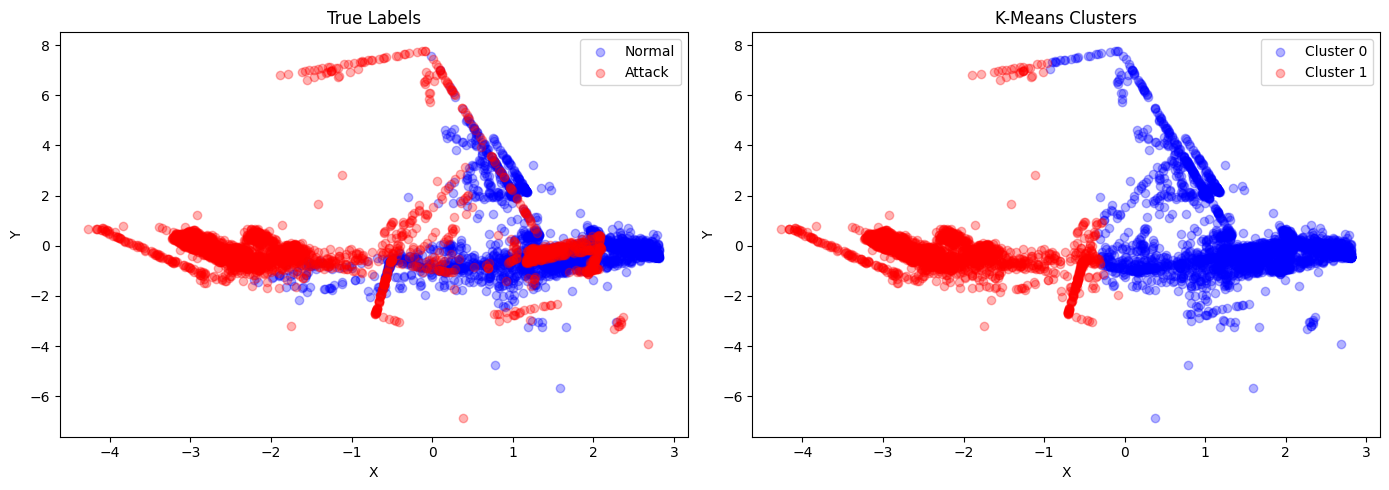

In [70]:
# using PCA to reduce 15 features down to 2 dimensions
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)

# plotting two side-by-side scatter plots
plt.figure(figsize=(14, 5))

# Plot 1: True labels
plt.subplot(1, 2, 1)
plt.scatter(x_pca[y_true==0, 0], x_pca[y_true==0, 1], color='blue', alpha=0.3, label='Normal')
plt.scatter(x_pca[y_true==1, 0], x_pca[y_true==1, 1], color='red',  alpha=0.3, label='Attack')
plt.title('True Labels')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

# Plot 2: K-Means cluster labels
plt.subplot(1, 2, 2)
plt.scatter(x_pca[y_pred==0, 0], x_pca[y_pred==0, 1], color='blue', alpha=0.3, label='Cluster 0')
plt.scatter(x_pca[y_pred==1, 0], x_pca[y_pred==1, 1], color='red',  alpha=0.3, label='Cluster 1')
plt.title('K-Means Clusters')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

plt.tight_layout()
plt.show()

# Task # 05
## Genetic Algorithm for Feature Selection


In [80]:
# parameters
POP_SIZE=10
GENERATIONS=10
MUTATION_RATE=0.1
N_FEATURES=15

#Step 1: creating initial population
population=[]

for i in range(POP_SIZE):
    chrom=[]

    for j in range(N_FEATURES):
        chrom.append(random.randint(0, 1))

    population.append(chrom)

best_score_history=[] # to track the best accuracy
best_chromosome=None
best_overall_fitness=0

for gen in range(GENERATIONS):
    fitness_scores=[]

    for chrom in population:
        selected=[]

        for i in range(N_FEATURES):
            if chrom[i]==1:
                selected.append(i)
                
        if len(selected)==0:
            fitness_scores.append(0.0)
            continue
            
        x_train_sel=x_train_scaled[:, selected]
        x_test_sel=x_test_scaled[:, selected]

        model=LogisticRegression(max_iter=1000)
        model.fit(x_train_sel, y_train)
        pred=model.predict(x_test_sel)
        acc=accuracy_score(y_test, pred)
        fitness_scores.append(acc)
        
    best_fitness = max(fitness_scores)
    best_idx = fitness_scores.index(best_fitness)
    best_score_history.append(best_fitness)
    
    if best_fitness > best_overall_fitness:
        best_overall_fitness = best_fitness
        best_chromosome      = population[best_idx][:]

    print(f"Gen {gen + 1}: Best accuracy = {best_fitness:.4f}, features used = {sum(population[best_idx])}")
    
    new_population=[]

    for _ in range(POP_SIZE):
        i1=random.randint(0, POP_SIZE-1)
        i2=random.randint(0, POP_SIZE-1)
        i3=random.randint(0, POP_SIZE-1)

        if fitness_scores[i1]>=fitness_scores[i2] and fitness_scores[i1]>=fitness_scores[i3]:
            new_population.append(population[i1][:])

        elif fitness_scores[i2]>=fitness_scores[i1] and fitness_scores[i2]>=fitness_scores[i3]:
            new_population.append(population[i2][:])

        else:
            new_population.append(population[i3][:])
            
    next_population=[]

    for i in range(0, POP_SIZE, 2):
        if i+1>=POP_SIZE:
            next_population.append(new_population[i][:])
            break
            
        point=random.randint(1, N_FEATURES - 1)
        child1=new_population[i][:point]+new_population[i+1][point:]
        child2=new_population[i+1][:point]+new_population[i][point:]
        
        for j in range(N_FEATURES):
            if random.random()<MUTATION_RATE:
                child1[j]=1-child1[j]
                
            if random.random()<MUTATION_RATE:
                child2[j]=1-child2[j]

        next_population.append(child1)
        next_population.append(child2)
        
    population=next_population[:POP_SIZE]

selected_feature_names=[]

for i in range(N_FEATURES):
    if best_chromosome[i]==1:
        selected_feature_names.append(feature_columns[i])

print("\n\nGA Results\n")
print(f"Best accuracy with selected features: {best_overall_fitness:.4f}")
print(f"Number of features selected: {len(selected_feature_names)} out of {N_FEATURES}")

lr_all=LogisticRegression(max_iter=1000)
lr_all.fit(x_train_scaled, y_train)
acc_all=accuracy_score(y_test, lr_all.predict(x_test_scaled))

print(f"\nLogistic Regression with ALL {N_FEATURES} features:{acc_all:.4f}")
print(f"Logistic Regression with GA-selected features: {best_overall_fitness:.4f}")

Gen 1: Best accuracy = 0.8925, features used = 7
,Gen 2: Best accuracy = 0.8967, features used = 10
,Gen 3: Best accuracy = 0.8942, features used = 10
,Gen 4: Best accuracy = 0.9033, features used = 12
,Gen 5: Best accuracy = 0.9167, features used = 12
,Gen 6: Best accuracy = 0.9167, features used = 12
,Gen 7: Best accuracy = 0.9167, features used = 12
,Gen 8: Best accuracy = 0.9175, features used = 12
,Gen 9: Best accuracy = 0.9175, features used = 12
,Gen 10: Best accuracy = 0.9167, features used = 12
,
,
,GA Results
,
,Best accuracy with selected features: 0.9175
,Number of features selected: 12 out of 15
,
,Logistic Regression with ALL 15 features:0.9150
,Logistic Regression with GA-selected features: 0.9175


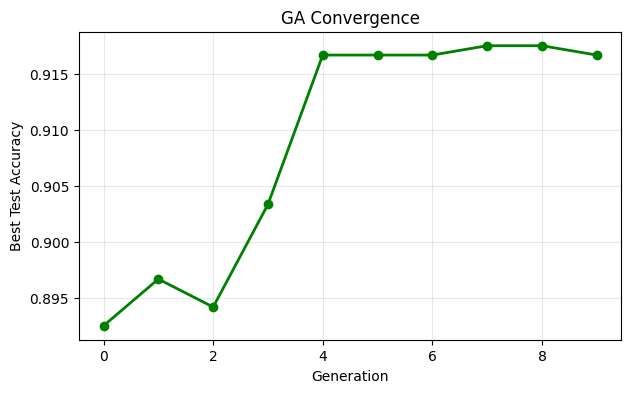

Number of generations run: 10
,Final best accuracy: 0.9167


In [81]:
plt.figure(figsize=(7, 4))
plt.plot(best_score_history, marker='o', color='green', linewidth=2)
plt.title('GA Convergence')
plt.xlabel('Generation')
plt.ylabel('Best Test Accuracy')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Number of generations run: {len(best_score_history)}")
print(f"Final best accuracy: {best_score_history[-1]:.4f}")